In [1]:
from daam import trace, set_seed
from diffusers import DiffusionPipeline
from matplotlib import pyplot as plt
import torch

In [2]:
model_id = 'stabilityai/sdxl-turbo'
device = 'cuda'

pipe = DiffusionPipeline.from_pretrained(model_id, use_auth_token=True, torch_dtype=torch.float16, use_safetensors=True, variant='fp16')
pipe = pipe.to(device)

C:\ProgramData\miniconda3\envs\daam_env\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
The config attributes {'feature_extractor': [None, None], 'image_encoder': [None, None]} were passed to StableDiffusionXLPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'feature_extractor': [None, None], 'image_encoder': [None, None]} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'reverse_transformer_layers_per_block': None} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


In [3]:
prompt = 'A dog and a cat'
gen = set_seed(0)  # for reproducibility
out = pipe(prompt, num_inference_steps=4, generator=gen)

  0%|          | 0/4 [00:00<?, ?it/s]

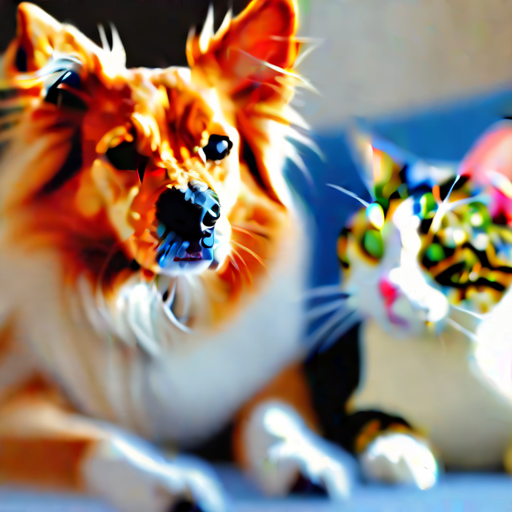

In [4]:
out.images[0]

  0%|          | 0/4 [00:00<?, ?it/s]

C:\ProgramData\miniconda3\envs\daam_env\lib\site-packages\daam\utils.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(*args, **kwargs)


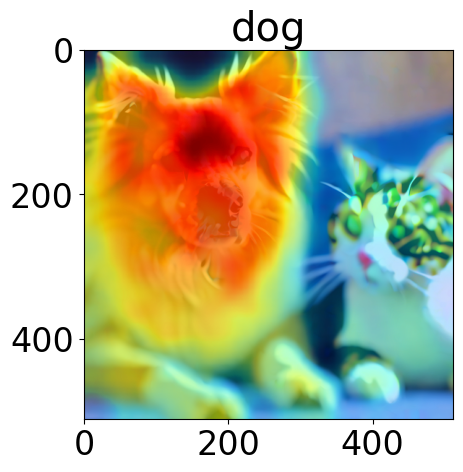

In [5]:
prompt = 'A dog and a cat'
gen = set_seed(0)  # for reproducibility

with torch.no_grad():
    with trace(pipe) as tc:
        out = pipe(prompt, num_inference_steps=4, generator=gen)
        heat_map = tc.compute_global_heat_map()
        heat_map = heat_map.compute_word_heat_map('dog')
        heat_map.plot_overlay(out.images[0])
        plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

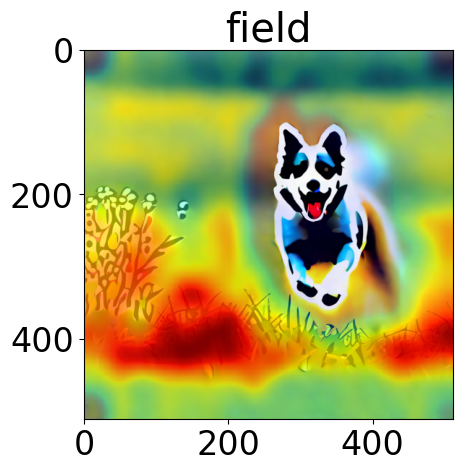

In [6]:
prompt = 'A dog runs across the field'
gen = set_seed(0)  # for reproducibility

with torch.no_grad():
    with trace(pipe) as tc:
        out = pipe(prompt, num_inference_steps=4, generator=gen)
        heat_map = tc.compute_global_heat_map()
        heat_map = heat_map.compute_word_heat_map('field')
        heat_map.plot_overlay(out.images[0])
        plt.show()